In [1]:
from google.colab.patches import cv2_imshow
import cv2
import numpy as np

In [2]:
import os
from google.colab import drive

drive.mount('/content/drive')

read_path = '/content/drive/MyDrive/agents_project2/'

Mounted at /content/drive


In [3]:
import zipfile
import os

zip_file_name = 'clothing_crops.zip'
zip_file_path = os.path.join(read_path, zip_file_name)
extract_dir = os.path.join('/content', 'clothing_crops')

# Create the extraction directory if it doesn't exist
os.makedirs(extract_dir, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"Successfully unzipped '{zip_file_name}' to '{extract_dir}'")

Successfully unzipped 'clothing_crops.zip' to '/content/clothing_crops'


In [4]:
train_img_path = os.path.join(extract_dir, 'content', 'crops', 'train')
test_img_path = os.path.join(extract_dir, 'content', 'crops', 'test')

In [5]:
def compute_features(base_path):
  hog = cv2.HOGDescriptor(_winSize=(128, 128), _blockSize=(16, 16), _blockStride=(8, 8), _cellSize=(8, 8), _nbins=9)
  feature_vecs = []
  labels = []
  for dir in os.listdir(base_path):
    label = dir.split('_')[1]
    dir = os.path.join(base_path, dir)
    for img_name in os.listdir(dir):
      img_name = os.path.join(dir, img_name)
      if os.path.isfile(img_name):
        img = cv2.imread(img_name)
        hog_feats = hog.compute(img)
        if np.all(hog_feats==0):
          print(f'Feature vector is all 0s!')
      else:
        print(f'{img_name} is not a valid file!')
      feature_vecs.append(hog_feats)
      labels.append(label)
  return np.vstack(feature_vecs), np.vstack(labels)

In [6]:
train_feats, train_labels = compute_features(train_img_path)
test_feats, test_labels = compute_features(test_img_path)

In [7]:
test_feats.shape

(2035, 8100)

In [8]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)
pca.fit(train_feats)
train_X = pca.transform(train_feats)
test_X = pca.transform(test_feats)

In [9]:
train_X.shape

(8298, 1655)

In [10]:
pca.explained_variance_ratio_.sum()

np.float32(0.95001745)

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(train_X)
train_X = scaler.transform(train_X)
test_X = scaler.transform(test_X)

In [12]:
from sklearn.svm import SVC


svm = SVC(kernel='linear', C=0.1)
svm.fit(train_X, train_labels.ravel())

SVC(C=0.1, kernel='linear')

In [13]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay

In [14]:
preds = svm.predict(test_X)
accuracy_score(test_labels, preds)

0.513022113022113

In [15]:
f1_score(test_labels, preds, average='weighted')

0.5151139270466364

In [16]:
cm = confusion_matrix(test_labels, preds, normalize='true')

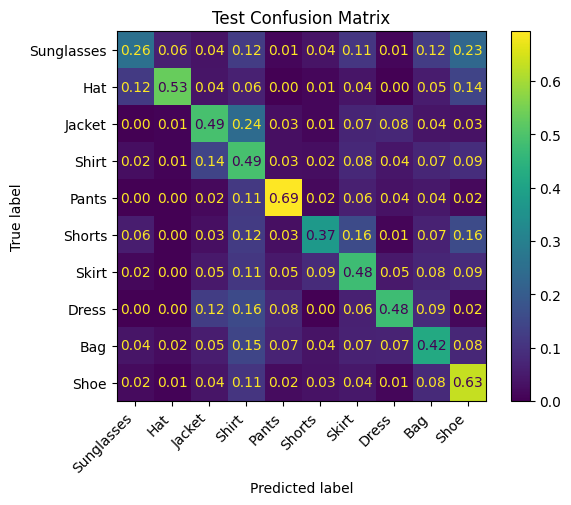

In [18]:
import matplotlib.pyplot as plt
disp = ConfusionMatrixDisplay(cm, display_labels=['Sunglasses', 'Hat', 'Jacket', 'Shirt', 'Pants', 'Shorts', 'Skirt', 'Dress', 'Bag', 'Shoe'])
disp.plot(values_format='.2f')
plt.title('Test Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.show()

In [19]:
# Problem: overfits on training data
train_preds = svm.predict(train_X)
accuracy_score(train_labels, train_preds)

1.0

In [21]:
f1_score(train_labels, train_preds, average='weighted')

1.0

In [22]:
# Class balance
np.unique_counts(train_labels)

UniqueCountsResult(values=array(['0.0', '1.0', '2.0', '3.0', '4.0', '5.0', '6.0', '7.0', '8.0',
       '9.0'], dtype='<U3'), counts=array([ 343,  273,  777, 1486,  508,  395,  697,  550, 1188, 2081]))

In [23]:
# Save for later usage
import joblib

joblib.dump(svm, '/content/svm_model.joblib')
joblib.dump(pca, '/content/pca_model.joblib')
joblib.dump(scaler, '/content/scaler_model.joblib')

['/content/scaler_model.joblib']